# Model 2 -- Minimal B-L: a gauged U(1) with a seesaw and a Z'

L. Basso, S. Moretti, G. M. Pruna, arXiv:1106.4462.


The minimal gauged $B-L$ model extends the Standard Model gauge group by $U(1)_{B-L}$, broken spontaneously by a new singlet scalar. That scalar's vacuum expectation value also generates Majorana masses for three right-handed neutrinos via the type-I seesaw, so gauge symmetry breaking and neutrino mass share a single new scale $v_{BL}$. The new $Z'$ gauge boson and the extra scalar mix with their Standard Model counterparts, subjecting the model to LEP contact-interaction bounds, a $Z'$ narrow-width requirement, and Higgs signal-strength measurements.

**What this notebook does.** BSMScanner separates *what a model is* (a declarative YAML specification: parameters, priors, derived quantities, observables, validity conditions, likelihoods) from *how it is scanned* (one of several interchangeable search engines). This notebook loads the model below, runs a small, fast scan live so you can see the mechanics end to end, and then loads the matched-budget, fixed-seed comparison across all four engines from the companion paper's benchmark study, together with its best-fit / allowed-region result and figure. The live demo uses a short budget and an illustrative seed — it is not the published comparison, and is not expected to reproduce it exactly.


## 1. Load the framework and the model

In [1]:
import sys, pathlib
REPO_ROOT = pathlib.Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT / "python"))

import pandas as pd
from bsm_scanner import load_model, compile_model, run_scan
import bsm_scanner

print("bsm_scanner", bsm_scanner.__version__)
print("repo root  :", REPO_ROOT)

bsm_scanner 0.1.2
repo root  : /sessions/rcw-012reqeed7ksc6e9zagwhruw/mnt/BSMScanner


## 2. The model specification

Every scanned parameter, its prior, and its range come straight out of the model's YAML file (`../models/minimal_bl/model.yaml`); nothing here is hand-written Python.

In [2]:
model = load_model("../models/minimal_bl/model.yaml")
print("model    :", model.metadata.name)
print("params   :", len(model.parameters), "scanned")
print("theory checks:", len(model.theory_checks))
print("likelihood terms:", len(model.likelihoods))

pd.DataFrame(
    [{"name": p.name, "prior": p.prior.value, "lower": p.lower, "upper": p.upper, "default": p.default}
     for p in model.parameters]
)

model    : minimal_bl_gauge
params   : 7 scanned
theory checks: 3
likelihood terms: 3


,name,prior,lower,upper,default
0,gBL,log,0.001000,1.00,0.10
1,vBL,log,1000.000000,100000.00,70000.00
2,mH2,log,130.000000,5000.00,800.00
3,sin_alpha,flat,-0.350000,0.35,0.05
4,yN1,log,0.000001,3.00,0.01
5,yN2,log,0.000001,3.00,0.02
6,yN3,log,0.000001,3.00,0.03


Likelihood terms declared on the model:

In [3]:
pd.DataFrame(
    [{"name": t.name, "kind": t.kind.value, "observable": t.observable} for t in model.likelihoods]
)

,name,kind,observable
0,lep_contact_bound,hard_cut,contact_scale
1,higgs_signal_strength,gaussian,HiggsSignalStrength
2,zprime_narrow_width,hard_cut,ZprimeWidthFractionProxy


For reference, here is the parameter block exactly as written in the YAML (this is the entire declarative input the physics below is built from):

In [4]:
print(pathlib.Path("../models/minimal_bl/model.yaml").read_text())

metadata:
  name: minimal_bl_gauge
  version: 0.1.0
  description: Minimal gauged B-L benchmark with a Zprime, singlet-breaking scalar, three right-handed neutrinos, Higgs mixing, and scan-ready precision/collider proxy observables.
  tags: [minimal_bl, b_minus_l, zprime, right_handed_neutrinos, higgs_mixing]
parameters:
- {name: gBL, value_type: real, scan: true, lower: 0.001, upper: 1.0, default: 0.1, prior: log}
- {name: vBL, value_type: real, scan: true, lower: 1000.0, upper: 100000.0, default: 70000.0, prior: log}
- {name: mH2, value_type: real, scan: true, lower: 130.0, upper: 5000.0, default: 800.0, prior: log}
- {name: sin_alpha, value_type: real, scan: true, lower: -0.35, upper: 0.35, default: 0.05, prior: flat}
- {name: yN1, value_type: real, scan: true, lower: 0.000001, upper: 3.0, default: 0.01, prior: log}
- {name: yN2, value_type: real, scan: true, lower: 0.000001, upper: 3.0, default: 0.02, prior: log}
- {name: yN3, value_type: real, scan: true, lower: 0.000001, upper: 3

## 3. A quick, live scan

This runs `serial_random` for `1500` evaluations at a throwaway seed, right here, so you can see the mechanics end to end in a few seconds. It is deliberately small and is **not** the matched-budget comparison used in the study below.

In [5]:
# A small, fast, live demo -- NOT the matched-budget study below.
model.scan.engine = "serial_random"
model.scan.seed = 1
model.scan.settings["max_evaluations"] = 1500

compiled = compile_model(model)
demo = run_scan(model, compiled, run_directory="runs/minimal_bl_demo")

n_eval = demo.summary["evaluations"]
n_valid = demo.summary["valid_points"]
print("evaluations  :", n_eval)
print("valid points :", n_valid, "(%.1f%% of this quick run)" % (100.0 * n_valid / n_eval))
print("best nLL in this quick run:", demo.summary["best_metric_value"])

points = pd.read_csv(demo.points_path)
points.head()

evaluations  : 1500
valid points : 1134 (75.6% of this quick run)
best nLL in this quick run: 3.2758031803158923e-13


,evaluation,status,valid,failure_reason,scanner_target,metric_value,total_nll,param::gBL,param::vBL,param::mH2,...,output::HeavyScalarMass,output::HeavyNeutrino1Mass,output::HeavyNeutrino2Mass,output::HeavyNeutrino3Mass,output::lambdaH,output::lambdaS,output::lambdaHS,likelihood::higgs_signal_strength,likelihood::lep_contact_bound,likelihood::zprime_narrow_width
0,1,ok,False,likelihood_input_invalid: lep_contact_bound,1.000000e+12,1.000000e+12,0.000000,0.002521,1874.19,674.732,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,ok,True,NaN,5.328840e-01,5.328840e-01,0.532884,0.001672,13794.10,1320.690,...,1320.692658,78.099358,2540.275682,0.531811,1.306785,0.004208,-0.140089,0.532884,0.0,0.0
2,3,ok,False,likelihood_input_invalid: lep_contact_bound,1.000000e+12,1.000000e+12,0.000000,0.018030,3159.05,377.187,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,ok,True,NaN,1.893270e-02,1.893270e-02,0.018933,0.176593,8246.11,397.427,...,397.427025,0.063068,0.069156,0.032693,0.147648,0.001145,-0.008674,0.018933,0.0,0.0
4,5,ok,True,NaN,2.502820e-03,2.502820e-03,0.002503,0.121418,19751.20,2325.090,...,2325.092201,75.609551,10.626801,0.477611,0.381013,0.006890,-0.083153,0.002503,0.0,0.0


## 4. The published engine comparison

Matched budget, identical seed (20260816). Unlike the scotogenic model, only one likelihood term here is continuous -- the other two are hard cuts -- so the global optimum is $n$LL $=0$ exactly, attained on a 6-dimensional degenerate plateau. "Coverage" counts occupied cells on a 25x25 grid over $(\log g_{BL}, \log v_{BL})$ among near-optimal points; 625 is full coverage.

In [6]:
pd.DataFrame([{'engine': 'serial_random', 'evaluations': 30000, 'valid': 21622, 'valid_pct': '72.1%', 'best_nLL': '2.21e-18', 'coverage': '386/625'}, {'engine': 'de_scipy', 'evaluations': 19720, 'valid': 19433, 'valid_pct': '98.5%', 'best_nLL': '0 (exact)', 'coverage': '452/625'}, {'engine': 'adaptive_diver', 'evaluations': 20100, 'valid': 19872, 'valid_pct': '98.9%', 'best_nLL': '0 (exact)', 'coverage': '442/625'}, {'engine': 'basin_scan', 'evaluations': 18661, 'valid': 14515, 'valid_pct': '77.8%', 'best_nLL': '0 (exact)', 'coverage': '262/625'}])[['engine', 'evaluations', 'valid', 'valid_pct', 'best_nLL', 'coverage']]

,engine,evaluations,valid,valid_pct,best_nLL,coverage
0,serial_random,30000,21622,72.1%,2.21e-18,386/625
1,de_scipy,19720,19433,98.5%,0 (exact),452/625
2,adaptive_diver,20100,19872,98.9%,0 (exact),442/625
3,basin_scan,18661,14515,77.8%,0 (exact),262/625


All four engines reach the optimum within 18-64 evaluations out of ~20-30k -- with a flat plateau there is nothing left to optimise. `basin_scan` is the *worst* performer here (262/625 coverage): it deliberately contracts into sub-boxes, which is exactly wrong when the optimum is a broad plateau rather than isolated islands -- the opposite of its scotogenic result. Engine choice should follow the likelihood's structure: focusing engines for fit-dominated models with sparse islands, broad samplers for constraint-dominated models with degenerate plateaus.

## 5. Allowed region (pooling near-optimal points from all four engines, 36,570 points)

In [7]:
pd.DataFrame([{'quantity': 'nLL at optimum', 'result': '0 (exact), degenerate'}, {'quantity': 'sin(alpha) at optimum', 'result': 0}, {'quantity': 'v_BL minimum reached', 'result': '3502.6 GeV (bound >= 3500)'}, {'quantity': 'M_Zprime range', 'result': '8.86 GeV -- 2.0e5 GeV'}, {'quantity': 'g_BL range', 'result': '1.01e-3 -- 1.0'}, {'quantity': 'min(M_Zprime / g_BL)', 'result': '7005.2 GeV (bound >= 7000)'}, {'quantity': 'LEP-bound violations among allowed points', 'result': 0}])[['quantity', 'result']]

,quantity,result
0,nLL at optimum,"0 (exact), degenerate"
1,sin(alpha) at optimum,0
2,v_BL minimum reached,3502.6 GeV (bound >= 3500)
3,M_Zprime range,8.86 GeV -- 2.0e5 GeV
4,g_BL range,1.01e-3 -- 1.0
5,min(M_Zprime / g_BL),7005.2 GeV (bound >= 7000)
6,LEP-bound violations among allowed points,0


The allowed points form a wedge whose upper-left edge traces the LEP contact-interaction line $M_{Z'} = 7\,\mathrm{TeV}\times g_{BL}$ almost exactly (saturating to within 0.07%) -- an independent check that the evaluator applies the hard cut correctly, not just a fit result.

### Figure

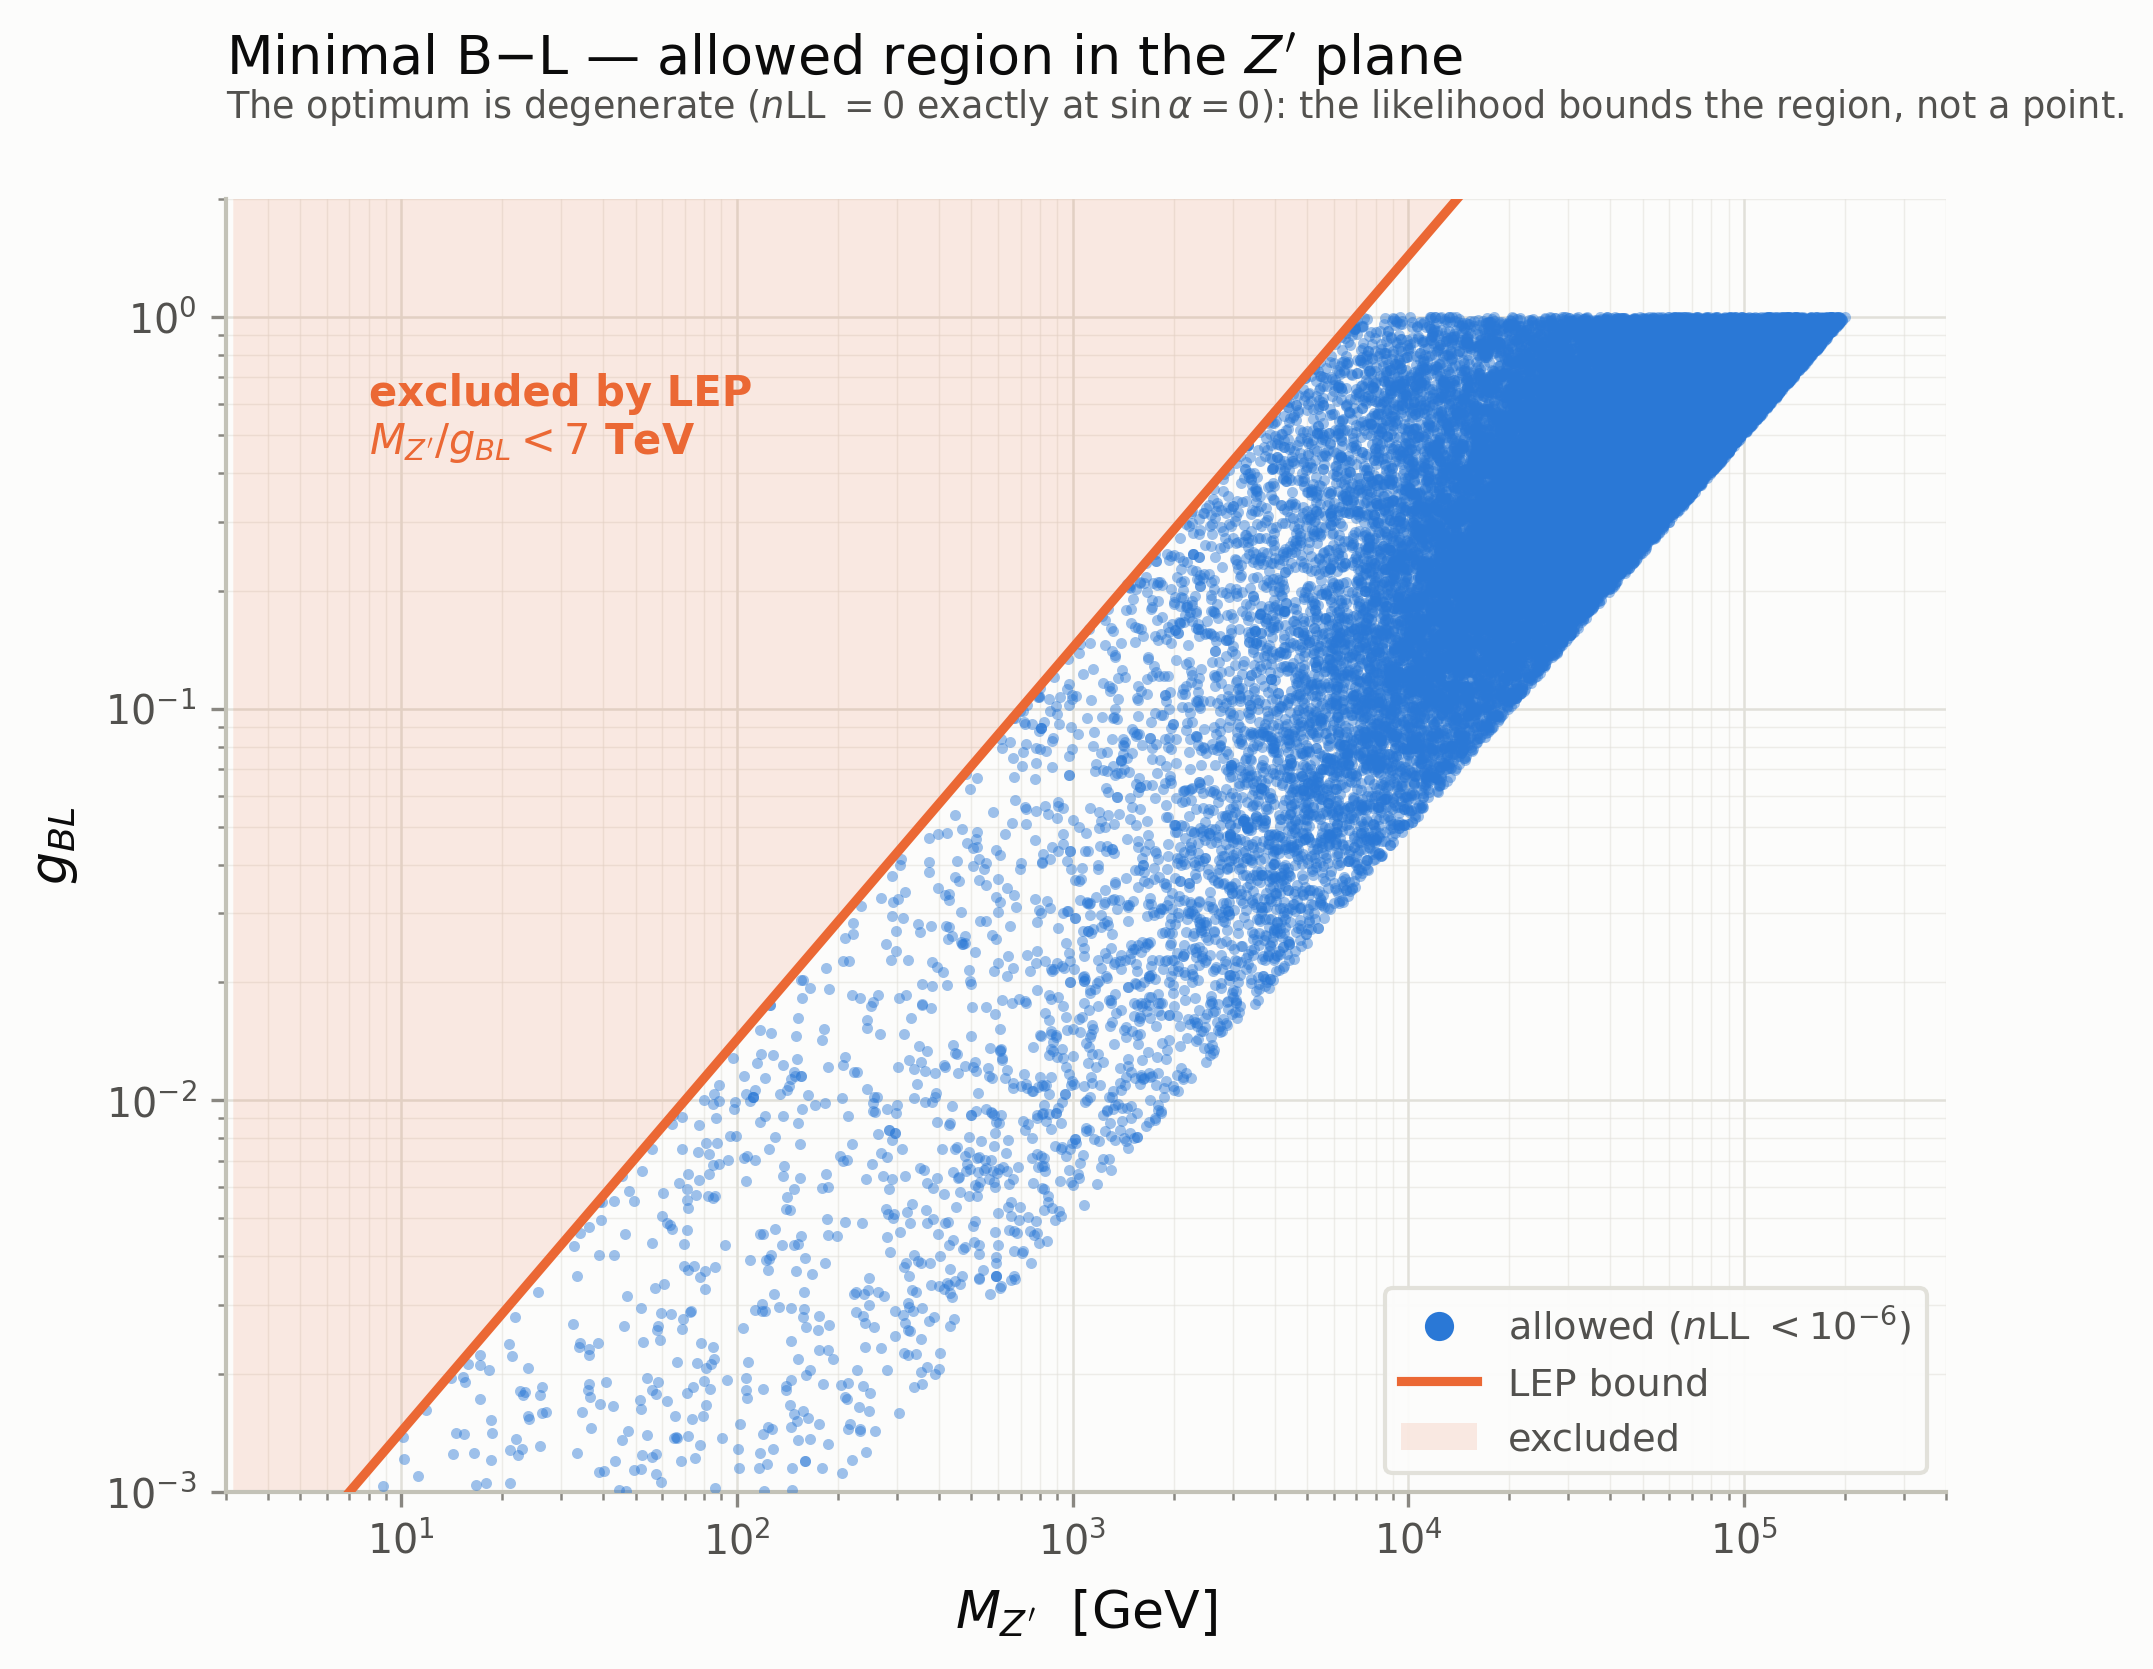

In [8]:
from IPython.display import Image, display
display(Image(filename="figures/minimal_bl_zprime.png"))

The allowed (M_Z', g_BL) wedge, its LEP contact-interaction edge, and the coverage achieved by each engine.

## 6. Caveats

The Higgs mixing and $Z'$ width here are simplified analytic proxies; the $Z'$ width fraction proxy is never active over the scanned range, so the only live constraints are the LEP contact bound and the Higgs signal strength. Real collider limits (CalcHEP/MadGraph widths) would cut into the wedge from the high-$g_{BL}$ side.

## 7. Reproducing the full study

The cell below is exactly the pattern used to produce the table in section 4 — shown, not executed, since a full matched-budget run can take a while.

In [ ]:
# NOT executed in this notebook (can take from seconds to several minutes per
# engine). Reproduces the matched-budget comparison from the study: seed
# 20260816, ~30k evaluations, one row per engine.
rows = []
for engine in ["serial_random", "de_scipy", "adaptive_diver", "basin_scan"]:
    m = load_model("../models/minimal_bl/model.yaml")
    m.scan.engine = engine
    m.scan.seed = 20260816
    m.scan.settings["max_evaluations"] = 30000
    c = compile_model(m)
    r = run_scan(m, c, run_directory=f"runs/{engine}_matched")
    rows.append({"engine": engine, **r.summary})
pd.DataFrame(rows)

---
BSMScanner: a declarative parameter-scanning framework for BSM physics. See the companion paper for the full seven-benchmark methodology study, and `notebooks/t43i_b1.ipynb` for a worked physics application built on top of it.